<a href="https://colab.research.google.com/github/Ravenhyo/Telecom-X/blob/main/Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   int64  
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport 

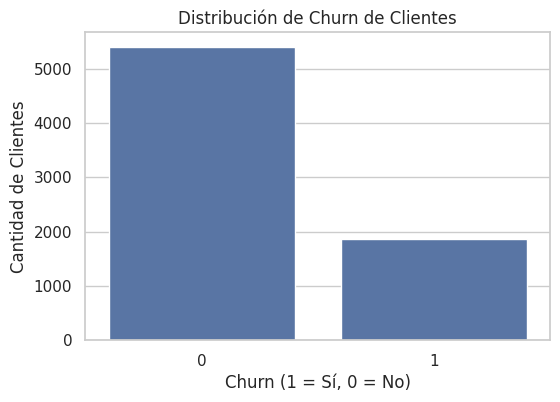

Porcentaje de Churn:
Churn
0    74.280996
1    25.719004
Name: proportion, dtype: float64


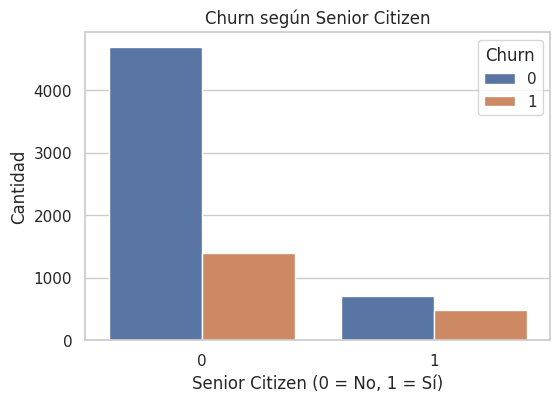

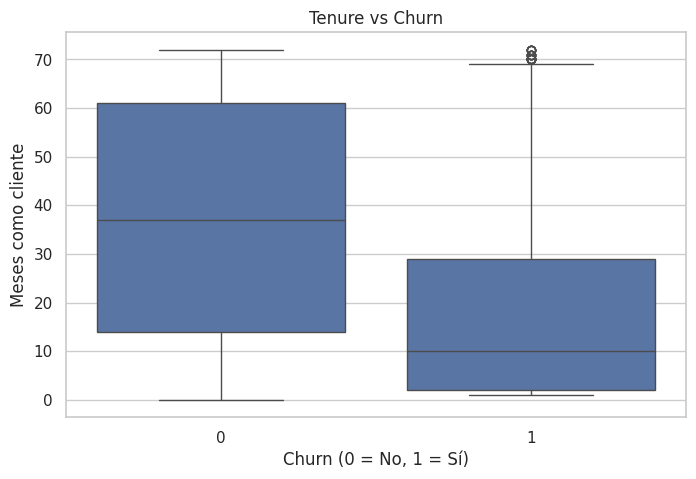

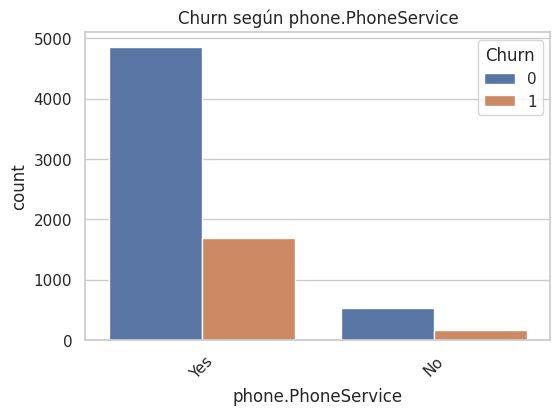

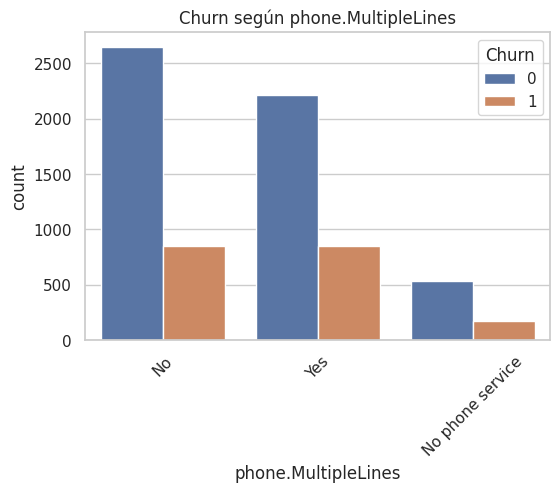

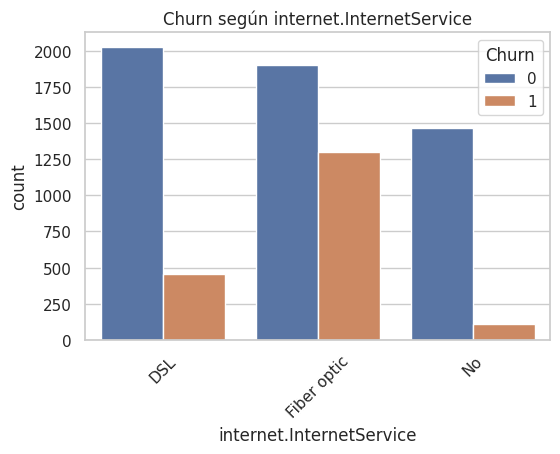

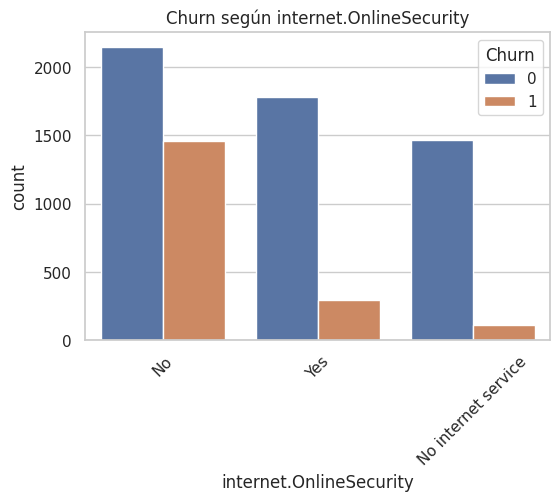

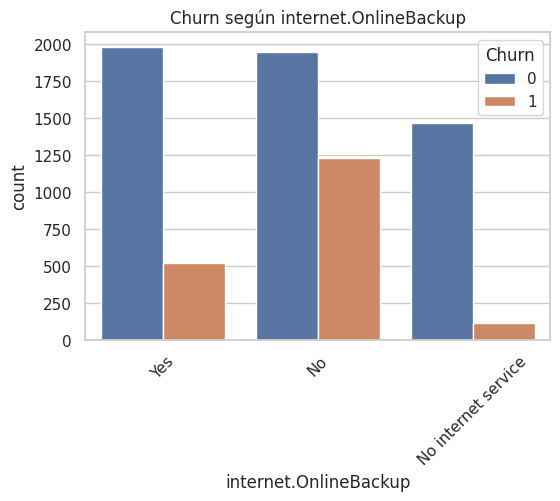

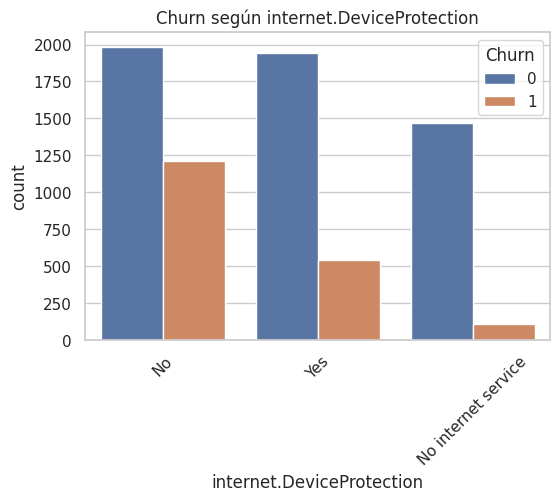

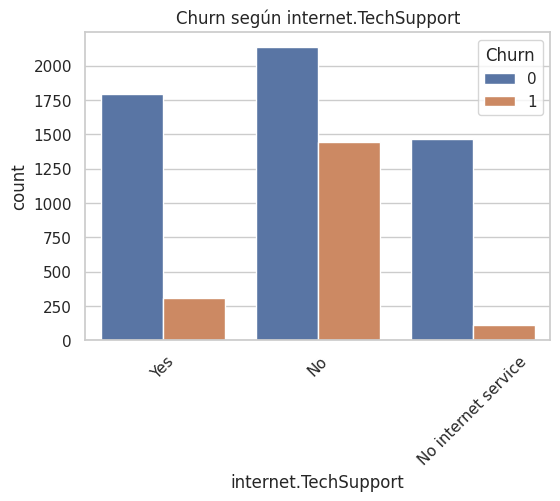

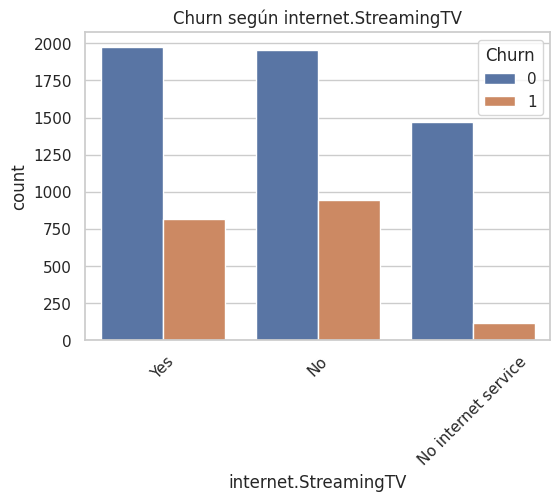

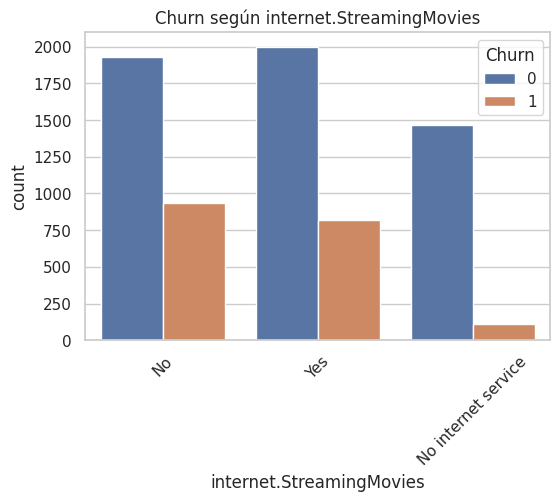

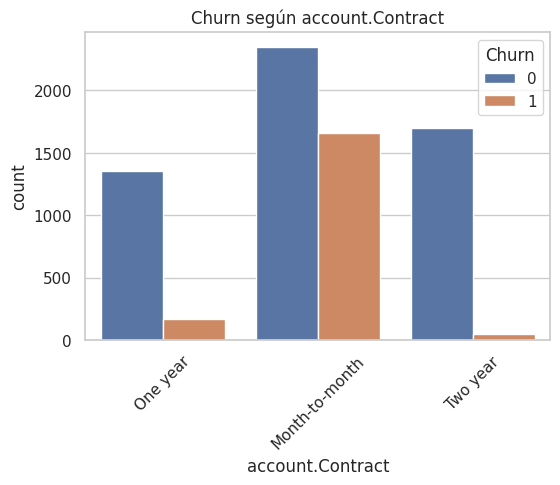

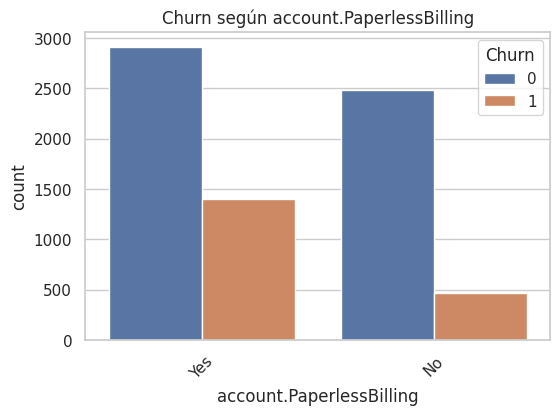

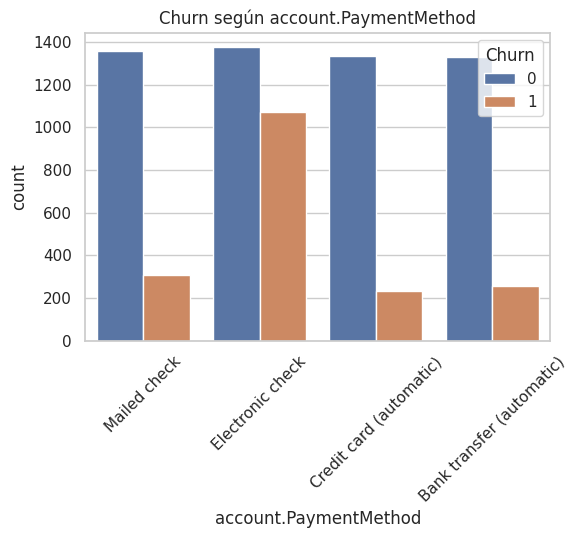

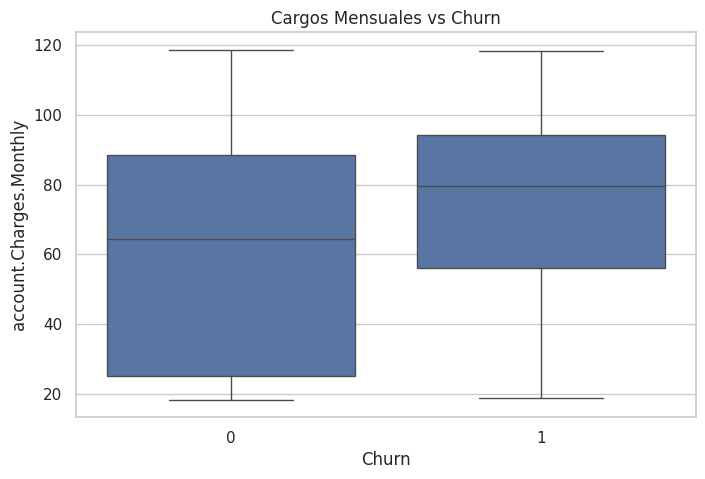

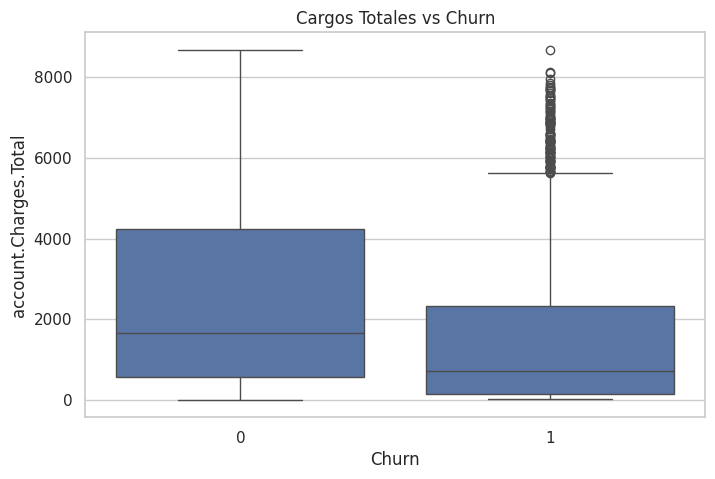

Correlación de variables numéricas con Churn:
Churn                      1.000000
account.Charges.Monthly    0.189866
customer.SeniorCitizen     0.146733
account.Charges.Total     -0.193345
customer.tenure           -0.344079
Name: Churn, dtype: float64


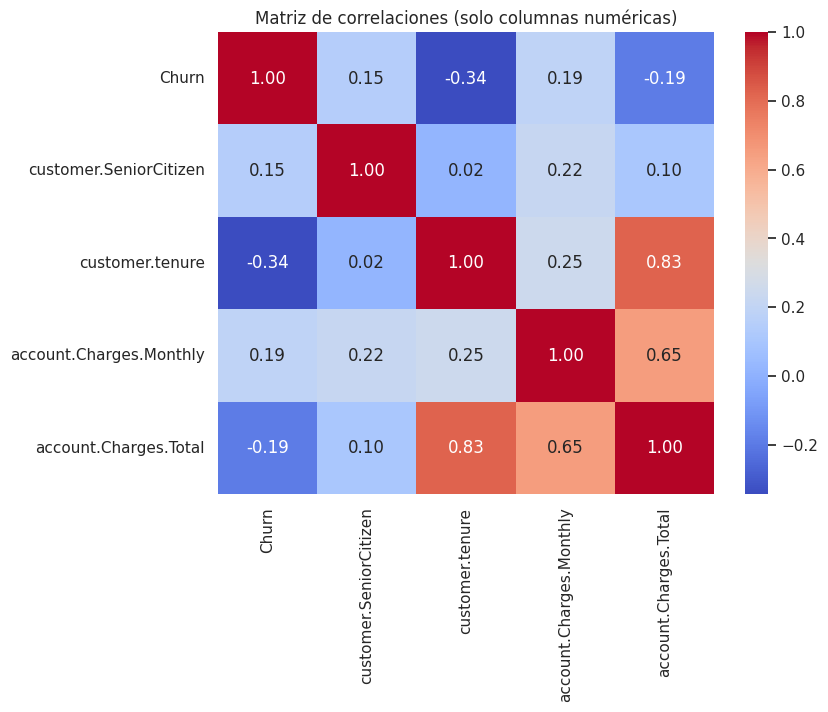

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests

%matplotlib inline
sns.set(style="whitegrid")

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"
data = requests.get(url).json()
df = pd.json_normalize(data)

#columna Churn
df['Churn'] = df['Churn'].replace('', 'No')        # reemplazar valores vacíos
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0}) # convertir a numérico

#limpiar columnas numéricas
df['customer.tenure'] = pd.to_numeric(df['customer.tenure'], errors='coerce').fillna(0)
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce').fillna(0)
df['account.Charges.Monthly'] = pd.to_numeric(df['account.Charges.Monthly'], errors='coerce').fillna(0)

print("Información del DataFrame:")
df.info()
df.head()

plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Distribución de Churn de Clientes")
plt.xlabel("Churn (1 = Sí, 0 = No)")
plt.ylabel("Cantidad de Clientes")
plt.show()

print("Porcentaje de Churn:")
print(df['Churn'].value_counts(normalize=True)*100)


plt.figure(figsize=(6,4))
sns.countplot(x='customer.SeniorCitizen', hue='Churn', data=df)
plt.title("Churn según Senior Citizen")
plt.xlabel("Senior Citizen (0 = No, 1 = Sí)")
plt.ylabel("Cantidad")
plt.show()


plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='customer.tenure', data=df)
plt.title("Tenure vs Churn")
plt.xlabel("Churn (0 = No, 1 = Sí)")
plt.ylabel("Meses como cliente")
plt.show()


servicios = [
    'phone.PhoneService', 'phone.MultipleLines',
    'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup',
    'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV',
    'internet.StreamingMovies'
]

for col in servicios:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f"Churn según {col}")
    plt.xticks(rotation=45)
    plt.show()


cuentas = ['account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod']

for col in cuentas:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Churn', data=df)
    plt.title(f"Churn según {col}")
    plt.xticks(rotation=45)
    plt.show()


plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='account.Charges.Monthly', data=df)
plt.title("Cargos Mensuales vs Churn")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='account.Charges.Total', data=df)
plt.title("Cargos Totales vs Churn")
plt.show()


num_df = df[['Churn', 'customer.SeniorCitizen', 'customer.tenure',
             'account.Charges.Monthly', 'account.Charges.Total']]

corr = num_df.corr()['Churn'].sort_values(ascending=False)
print("Correlación de variables numéricas con Churn:")
print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(num_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de correlaciones (solo columnas numéricas)")
plt.show()

# Guardar
df.to_csv("TelecomX_AnalisisListo.csv", index=False)

Conclusiones finales – Telecom X

Noté que muchos clientes que se van tienen contratos de “Month-to-month” y usan servicios como Internet de fibra óptica, que parece ser más inestable o costoso.

Los clientes que llevaron poco tiempo con la empresa tienden a irse más rápido, mientras que los que llevan años son más fieles.

También se ve que los clientes que tienen cargos mensuales altos o que usan varios servicios adicionales, como streaming o soporte técnico, tienen más probabilidad de irse.

En resumen, el churn parece estar relacionado con tipo de contrato, tiempo como cliente y cantidad de servicios contratados.

Debo admitir que me costó mucho entender todos los datos y organizar los gráficos, pero logré limpiar la información y ver claramente estos patrones.


